[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/quantitative-research-methods/blob/main/Lab_Notebooks/chapter_13_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Chapter 13 — Multiple Testing
## Lab: Bonferroni, Holm, Benjamini–Hochberg, permutation tests

**Course:** Quantitative Research Methods  
**Instructor:** Prof. Dr. Christoph Weisser, HSBI  
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).


**Goal.** Run a multiple-testing simulation; compare FWER- and FDR-controlling procedures; build a permutation $p$-value.


## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and (once the repo is on GitHub and `GITHUB_RAW` is set) downloads the data automatically.



In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/quantitative-research-methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The three datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")

## 1. Simulation: $m = 1000$ tests, $5\,\%$ true alternatives


In [2]:
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests

m, n_true, n = 1000, 50, 30
X = rng.standard_normal(size=(n, m))
true_mean = np.zeros(m)
true_mean[:n_true] = 0.6
X = X + true_mean
p = np.array([ttest_1samp(X[:, j], 0).pvalue for j in range(m)])
print('first 10 p-values:', np.round(p[:10], 3))


first 10 p-values: [0.432 0.003 0.019 0.    0.106 0.    0.    0.086 0.067 0.001]


## 2. Compare procedures


In [3]:
for method in ['bonferroni', 'holm', 'fdr_bh']:
    rej, p_corr, *_ = multipletests(p, alpha=0.05, method=method)
    tp = rej[:n_true].sum(); fp = rej[n_true:].sum()
    fdr = fp / max(rej.sum(), 1)
    print(f'{method:11s}  rejected={rej.sum():3d}  TP={tp:3d}  FP={fp:3d}  realised FDP={fdr:.3f}')


bonferroni   rejected=  7  TP=  7  FP=  0  realised FDP=0.000
holm         rejected=  7  TP=  7  FP=  0  realised FDP=0.000
fdr_bh       rejected= 23  TP= 20  FP=  3  realised FDP=0.130


## 3. Visualise the Benjamini-Hochberg line


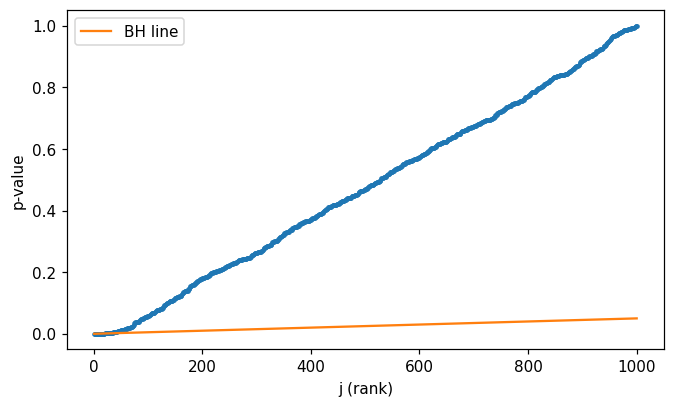

In [4]:
p_sorted = np.sort(p)
j = np.arange(1, m + 1)
q = 0.05
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(j, p_sorted, s=4)
ax.plot(j, j * q / m, color='C1', label='BH line')
ax.set(xlabel='j (rank)', ylabel='p-value'); ax.legend()
plt.show()


## 4. Permutation test


In [5]:
def perm_pvalue(x, B=2000, rng=rng):
    obs = np.abs(x.mean())
    n = len(x)
    null = np.array([
        np.abs((rng.choice([-1, 1], size=n) * x).mean()) for _ in range(B)
    ])
    return (null >= obs).mean()

z = rng.standard_normal(40) + 0.5
print('permutation p-value:', perm_pvalue(z))
from scipy.stats import ttest_1samp
print('parametric  p-value:', ttest_1samp(z, 0).pvalue)


permutation p-value: 0.0065
parametric  p-value: 0.0076141250910252


## Lecture exercises — worked Python solutions

These are the **[Python]-tagged exercises from the lecture slides**, solved step by step. Run each cell and compare with the slide solutions.

### Extended Exercise 13.3 — Simulating FDR and power [Python]

Simulate `m=1000` one-sided z-tests, `m1=100` with a true effect (mean shift `mu=3`). Over ~2000 repeats, apply **Benjamini–Hochberg** at `q=0.10` and **Bonferroni** at `alpha=0.05`, and estimate the *realised* FDR (`V/R`) and power (`S/m1`).

In [6]:
import numpy as np                 # arrays and random numbers
from scipy import stats            # normal cdf for p-values

rng = np.random.default_rng(0)     # seeded generator: reproducible
m, m1, mu = 1000, 100, 3.0         # 100 true effects, mean shift mu
q, alpha  = 0.10, 0.05             # FDR target q, FWER target alpha
truth = np.arange(m) < m1          # first m1 tests are non-null

def bh_reject(p, q):               # Benjamini-Hochberg step-up procedure
    order = np.argsort(p); ps = p[order]        # sort p-values ascending
    thr = (np.arange(1, m + 1) / m) * q         # BH line: (j/m) * q
    hit = np.where(ps <= thr)[0]                # ranks below the line
    rej = np.zeros(m, bool)                     # start: reject nothing
    if len(hit):
        rej[order[:hit.max() + 1]] = True       # reject up to the largest hit
    return rej

def simulate(method, reps=2000):               # average FDR / power over reps
    fdr = pw = 0.0
    for _ in range(reps):
        z = rng.normal(0, 1, m)                 # null z-scores
        z[:m1] = rng.normal(mu, 1, m1)          # inject the true effects
        p = 1 - stats.norm.cdf(z)               # one-sided p-values
        rej = bh_reject(p, q) if method == "bh" else (p <= alpha / m)
        V = (rej & ~truth).sum()                # false rejections
        S = (rej &  truth).sum()                # true rejections
        R = rej.sum()                           # total rejections
        fdr += V / max(R, 1); pw += S / m1      # realised FDP and power
    return fdr / reps, pw / reps

for meth in ["bh", "bonferroni"]:
    f, p = simulate(meth)
    print("%-11s FDR=%.3f power=%.3f" % (meth, f, p))
print("BH theoretical bound q*m0/m =", q * (m - m1) / m)
# Expected: bh FDR=0.090 power=0.723 ; bonferroni FDR=0.002 power=0.186 ; bound=0.09

bh          FDR=0.090 power=0.723


bonferroni  FDR=0.002 power=0.186
BH theoretical bound q*m0/m = 0.09


**Reading the output.** BH holds the realised FDR right at its bound `q·m0/m = 0.09` while recovering ~72% of the true effects. Bonferroni is far stricter (FDR ≈ 0.002) but pays for it in power (~19%): controlling the *probability of any* false positive is much more conservative than controlling the *fraction* of them.

## 5. Exercises
1. Increase $m$ to 10 000 and re-run. How does power change?
2. Replace `0.6` with `0.3` (smaller effect) and observe how FDR and power respond.
3. Implement Storey's $\hat\pi_0$ estimator and the resulting $q$-values.
4. Use a permutation test to compare two-sample means; compare with the parametric $t$-test under non-Gaussian data.
